https://jakevdp.github.io/PythonDataScienceHandbook/05.01-what-is-machine-learning.html

https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.02-Introducing-Scikit-Learn.ipynb#scrollTo=FiJ9ldR6YHBZ

https://scikit-learn.org/stable/

The Scikit-Learn API is designed with the following guiding principles in mind, as outlined in the [Scikit-Learn API paper](http://arxiv.org/abs/1309.0238). In practice, these principles make Scikit-Learn very easy to use, once the basic principles are understood.

- *Consistency*: All objects share a common interface drawn from a limited set of methods, with consistent documentation.
All models share the same basic interface with the same method names (fit, predict, transform, score, etc.).



In [ ]:
# Not runnable
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lin = LinearRegression()
rf = RandomForestRegressor()

lin.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_lin = lin.predict(X_test)
y_pred_rf = rf.predict(X_test)


- *Inspection*: All model parameters and learned attributes are accessible as public attributes — nothing is hidden.

In [ ]:
# Not runnable
model = LinearRegression(fit_intercept=False)
# There is NO intercept term.
# The regression line is forced to pass through:(0,0)
model.fit(X, y)

print(model.coef_)                # learned model weights
print(model.intercept_)           # learned intercept, will print zero when fit_intercept = 0

- *Limited object hierarchy*: Scikit-Learn doesn't introduce custom dataset types. Instead, algorithms use NumPy arrays, Pandas DataFrames, or SciPy sparse matrices.

In [ ]:
# Not runnable
from sklearn.svm import SVC
import pandas as pd

df = pd.read_csv("data.csv")
X = df[["age", "income"]]
y = df["label"]

model = SVC()
model.fit(X, y)   # Works directly on DataFrames

- *Composition*: Many machine learning tasks can be expressed as sequences of more fundamental algorithms,
  and Scikit-Learn makes use of this wherever possible.

Complex ML workflows are built by combining simple components.This is how Pipelines, ColumnTransformers work.

Pipeline chains multiple processing steps.

StandardScaler standardizes features → mean = 0, std = 1.

LogisticRegression is the classifier we want to use.

In [ ]:
# Not runnable
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "salary"]),
        ("cat", OneHotEncoder(), ["gender", "city"])
    ]
)

model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression())
])

model.fit(X_train, y_train)

Every step except the last must be a transformer
(transforms data → returns new transformed data).

The last step is usually a classifier or regressor (an estimator).

- *Sensible defaults*: When models require user-specified parameters, the library defines an appropriate default value. Models provide reasonable starting parameters so beginners can use them immediately.

### Basics of the API

Most commonly, the steps in using the Scikit-Learn Estimator API are as follows:

1. Choose a class of model by importing the appropriate estimator class from Scikit-Learn.
2. Choose model hyperparameters by instantiating this class with desired values.
3. Arrange data into a features matrix and target vector, as outlined earlier in this chapter.
4. Fit the model to your data by calling the `fit` method of the model instance.
5. Apply the model to new data:
   - For supervised learning, often we predict labels for unknown data using the `predict` method.
   - For unsupervised learning, we often transform or infer properties of the data using the `transform` or `predict` method.

We will now step through several simple examples of applying supervised and unsupervised learning methods.

## 1. Choose a class of model

https://scikit-learn.org/stable/modules/linear_model.html

In [1]:
from sklearn.linear_model import LinearRegression

## 2. Choose model hyperparameters


- Would we like to fit for the offset (i.e., *y*-intercept)?
- Would we like the model to be normalized?
- Would we like to preprocess our features to add model flexibility?
- What degree of regularization would we like to use in our model?
- How many model components would we like to use?

In Scikit-Learn, hyperparameters are chosen by passing values at model instantiation.

Keep in mind that when the model is instantiated, the only action is the storing of these hyperparameter values.
In particular, we have not yet applied the model to any data: the Scikit-Learn API makes very clear the distinction between *choice of model* and *application of model to data*.

In [2]:
model = LinearRegression(fit_intercept=True)
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 3. Arrange data into a features matrix and target vector



Here each row of the data refers to a single observed flower, and the number of rows is the total number of flowers in the dataset.
In general, we will refer to the rows of the matrix as *samples*, and the number of rows as `n_samples`.

Likewise, each column of the data refers to a particular quantitative piece of information that describes each sample.
In general, we will refer to the columns of the matrix as *features*, and the number of columns as `n_features`.

In [3]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.info()

In [4]:
df["target"].values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### The Features Matrix

The table layout makes clear that the information can be thought of as a two-dimensional numerical array or matrix, which we will call the *features matrix*.
By convention, this matrix is often stored in a variable named `X`.
The features matrix is assumed to be two-dimensional, with shape `[n_samples, n_features]`, and is most often contained in a NumPy array or a Pandas `DataFrame`, though some Scikit-Learn models also accept SciPy sparse matrices.

The samples (i.e., rows) always refer to the individual objects described by the dataset.
For example, a sample might represent a flower, a person, a document, an image, a sound file, a video, an astronomical object, or anything else you can describe with a set of quantitative measurements.

The features (i.e., columns) always refer to the distinct observations that describe each sample in a quantitative manner.
Features are often real-valued, but may be Boolean or discrete-valued in some cases.

### The Target Array

In addition to the feature matrix `X`, we also generally work with a *label* or *target* array, which by convention we will usually call `y`.
The target array is usually one-dimensional, with length `n_samples`, and is generally contained in a NumPy array or Pandas `Series`.
The target array may have continuous numerical values, or discrete classes/labels.
While some Scikit-Learn estimators do handle multiple target values in the form of a two-dimensional, `[n_samples, n_targets]` target array, we will primarily be working with the common case of a one-dimensional target array.

A common point of confusion is how the target array differs from the other feature columns. The distinguishing characteristic of the target array is that it is usually the quantity we want to *predict from the features*: in statistical terms, it is the dependent variable.
For example, given the preceding data we may wish to construct a model that can predict the species of flower based on the other measurements; in this case, the `species` column would be considered the target array.

For use in Scikit-Learn, we will extract the features matrix and target array from the `DataFrame`, which we can do using some of the Pandas `DataFrame` operations.

In [5]:
X_iris = df.drop('target', axis=1)
X_iris.shape

(150, 4)

In [6]:
y_iris = iris['target']
y_iris.shape

(150,)

Reshaping example with a mock dataset

In [7]:
import numpy as np

rng = np.random.RandomState(42)

x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
print(x.shape)
print(y.shape)


(50,)
(50,)


In [8]:
x

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

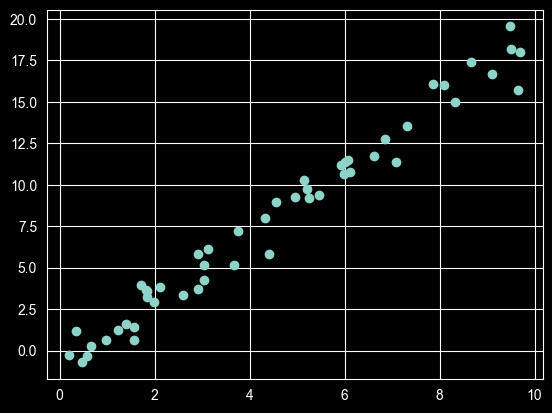

In [10]:
import matplotlib.pyplot as plt
plt.scatter(x, y);

Previously we examined the Scikit-Learn data representation, which requires a two-dimensional features matrix and a one-dimensional target array.
Here our target variable `y` is already in the correct form (a length-`n_samples` array), but we need to resize the data `x` to make it a matrix of size `[n_samples, n_features]`.
In this case, this amounts to a simple reshaping of the one-dimensional array:

In [11]:
X = x.reshape(-1, 1)
X.shape

(50, 1)

## 4. Fit model to the data

We train and fit our model with the fit function. Model-dependency internal computations take place and the results are stored.

All model parameters learned during this process are stored with trailing underscores.

In [12]:
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
model.coef_

array([1.9776566])

In [14]:
model.intercept_

np.float64(-0.903310725531111)

## 5. Predict labels for unknown data

New data = grid of x values

We find what the model predicts as y.

In [15]:
x_test = np.linspace(-1, 11)
print(x_test)
print(x_test.shape)

[-1.         -0.75510204 -0.51020408 -0.26530612 -0.02040816  0.2244898
  0.46938776  0.71428571  0.95918367  1.20408163  1.44897959  1.69387755
  1.93877551  2.18367347  2.42857143  2.67346939  2.91836735  3.16326531
  3.40816327  3.65306122  3.89795918  4.14285714  4.3877551   4.63265306
  4.87755102  5.12244898  5.36734694  5.6122449   5.85714286  6.10204082
  6.34693878  6.59183673  6.83673469  7.08163265  7.32653061  7.57142857
  7.81632653  8.06122449  8.30612245  8.55102041  8.79591837  9.04081633
  9.28571429  9.53061224  9.7755102  10.02040816 10.26530612 10.51020408
 10.75510204 11.        ]
(50,)


In [16]:
X_test = x_test.reshape(-1,1)
print(X_test)
print(X_test.shape)

[[-1.        ]
 [-0.75510204]
 [-0.51020408]
 [-0.26530612]
 [-0.02040816]
 [ 0.2244898 ]
 [ 0.46938776]
 [ 0.71428571]
 [ 0.95918367]
 [ 1.20408163]
 [ 1.44897959]
 [ 1.69387755]
 [ 1.93877551]
 [ 2.18367347]
 [ 2.42857143]
 [ 2.67346939]
 [ 2.91836735]
 [ 3.16326531]
 [ 3.40816327]
 [ 3.65306122]
 [ 3.89795918]
 [ 4.14285714]
 [ 4.3877551 ]
 [ 4.63265306]
 [ 4.87755102]
 [ 5.12244898]
 [ 5.36734694]
 [ 5.6122449 ]
 [ 5.85714286]
 [ 6.10204082]
 [ 6.34693878]
 [ 6.59183673]
 [ 6.83673469]
 [ 7.08163265]
 [ 7.32653061]
 [ 7.57142857]
 [ 7.81632653]
 [ 8.06122449]
 [ 8.30612245]
 [ 8.55102041]
 [ 8.79591837]
 [ 9.04081633]
 [ 9.28571429]
 [ 9.53061224]
 [ 9.7755102 ]
 [10.02040816]
 [10.26530612]
 [10.51020408]
 [10.75510204]
 [11.        ]]
(50, 1)


In [17]:
yfit = model.predict(X_test)

In [18]:
yfit.shape

(50,)

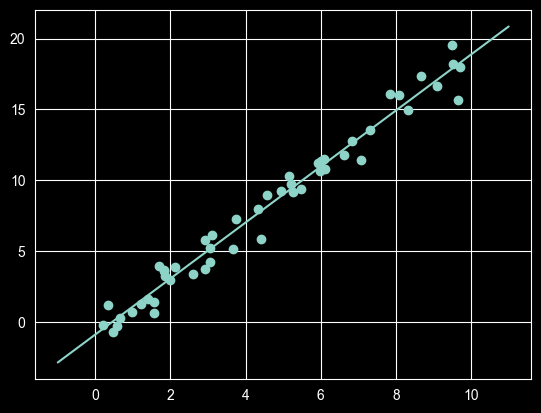

In [20]:
plt.scatter(x, y)
plt.plot(X_test, yfit);

# Python Lab: Validation & Unsupervised Learning

**Topics:**
1. **Model Evaluation:** Train/Test Splits and Cross-Validation.
2. **Dimensionality Reduction:** Principal Component Analysis (PCA).
3. **Clustering:** K-Means.

**Dataset:** We will continue using the **Iris dataset**, as it is perfect for visualizing 4 dimensions reduced to 2, and seeing how distinct the 3 species really are.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_iris

# 1. Load Data
iris = load_iris()
X = iris.data
y = iris.target

print(f"Feature Shape: {X.shape}") # 150 samples, 4 features
print(f"Target Shape: {y.shape}")

Feature Shape: (150, 4)
Target Shape: (150,)


## Part 1: Model Validation (Cross-Validation)

**Testing on the same data you trained on is a "sin" in Machine Learning**. It leads to overfitting (memorization).

### 1.1 The Holdout Set (Train/Test Split)
We hide a portion of the data during training to test the model's generalization later.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Split the data (50% train, 50% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.5)

# 2. Choose model (K-Nearest Neighbors is simple for classification)
model = KNeighborsClassifier(n_neighbors=3)

# 3. Fit on TRAINING data only
model.fit(X_train, y_train)

# 4. Predict on TEST data
y_pred = model.predict(X_test)

# 5. Score
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred):.2f}")

Accuracy on test set: 0.93


### 1.2 Cross-Validation (K-Fold)
The holdout set has a problem: what if we accidentally split the "easy" data into the test set? The accuracy score might be misleading.

**Cross-Validation** splits the data into *K* folds. It trains on *K-1* folds and tests on the remaining fold, rotating until every point has been used for testing.

In [23]:
from sklearn.model_selection import cross_val_score

model2 = KNeighborsClassifier(n_neighbors=1)

# We use the full X and y here; the function handles the splitting internally
scores = cross_val_score(model2, X, y, cv=5) # 5-Fold CV

print(f"Scores for each fold: {scores}")
print(f"Average Accuracy: {scores.mean():.2f}")

Scores for each fold: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Average Accuracy: 0.96


## Part 2: Dimensionality Reduction (PCA)

The Iris dataset has 4 features (4 Dimensions): Sepal Length, Sepal Width, Petal Length, Petal Width.
Humans cannot visualize 4D data.

**Principal Component Analysis (PCA)** is a technique to reduce dimensions while keeping the most important relationships (variance) between points.

We will squash 4 dimensions down to 2 dimensions.

In [24]:
from sklearn.decomposition import PCA

# 1. Choose model
pca = PCA(n_components=2) # We want 2D output

# 2. Fit model (Unsupervised: notice we only pass X, not y!)
pca.fit(X)

# 3. Transform data
X_2D = pca.transform(X)

print(f"Original shape: {X.shape}")
print(f"New shape:      {X_2D.shape}")

Original shape: (150, 4)
New shape:      (150, 2)


In [25]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [26]:
X_2D

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

Now we can visualize the 4D Iris dataset on a standard 2D X-Y plot. We will color the dots by their species `y` to see if the species are distinct.

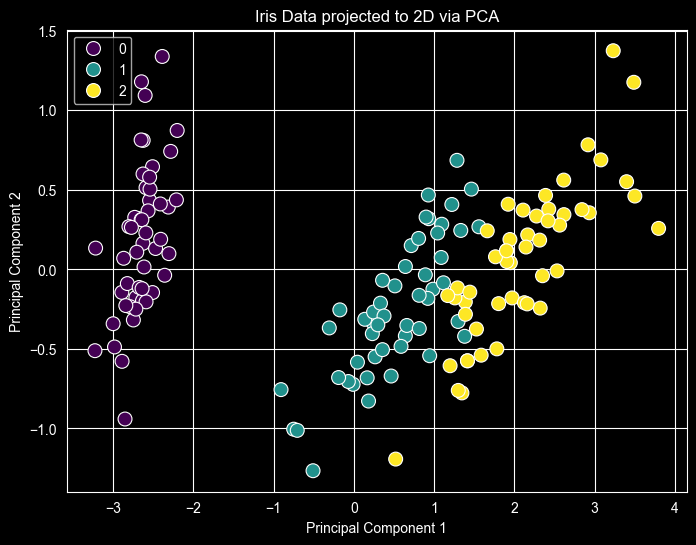

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2D[:, 0], # Take all rows from column 0 → This gives Principal Component 1
                y=X_2D[:, 1], # Take all rows from column 1 → This gives Principal Component 2
                hue=y,
                palette='viridis', s=100)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Iris Data projected to 2D via PCA')
plt.show()

## Part 3: K-Means Clustering

In the plot above, we used the known labels (`y`) to color the dots.
**What if we didn't have labels?** What if we just scraped data from the web and wanted to find natural groups?

**K-Means** is a clustering algorithm. It tries to find center points (centroids) for $k$ groups.

In [28]:
from sklearn.cluster import KMeans

# 1. Choose model
# We tell it to find 3 clusters (since we know there are 3 species, usually you have to guess this)
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Fit model (Unsupervised: X only)
kmeans.fit(X)

# 3. Predict clusters
y_kmeans = kmeans.predict(X)

print("Cluster labels assigned by K-Means:")
print(y_kmeans)

Cluster labels assigned by K-Means:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


### Visualizing the Clusters

Let's plot the PCA projection again, but this time, we color the dots based on **what K-Means thinks the groups are**, not what the actual species are.

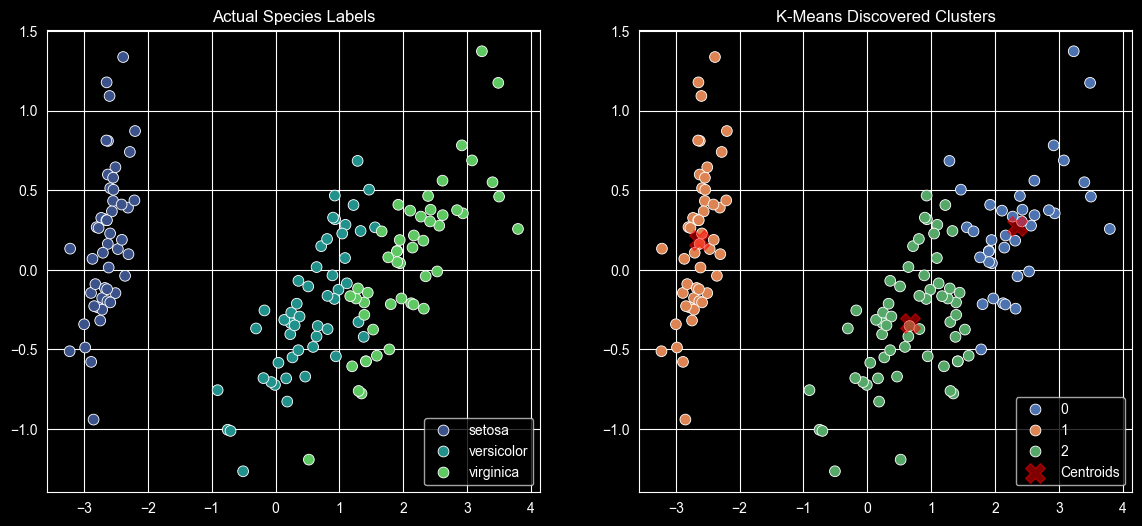

In [29]:
plt.figure(figsize=(14, 6))

# Plot 1: Actual Species (Ground Truth)
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=iris.target_names[y], palette='viridis', s=60)
plt.title('Actual Species Labels')

# Plot 2: K-Means Clusters
plt.subplot(1, 2, 2)
# Note: Cluster 0, 1, 2 are arbitrary math labels, they don't necessarily match Setosa/Versicolor order
sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=y_kmeans, palette='deep', s=60)

# Plot the centers of the clusters (we must project them to 2D using the same PCA to visualize)
centers_2D = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_2D[:, 0], centers_2D[:, 1], c='red', s=200, alpha=0.5, marker='X', label='Centroids')

plt.title('K-Means Discovered Clusters')
plt.legend()
plt.show()

### Discussion
Compare the two plots above.
1. Did K-Means successfully isolate the "Setosa" (far left) group?
2. Did K-Means struggle to separate the two overlapping groups on the right? (Unsupervised learning is hard when data overlaps!).

In [ ]:
# =============================
# 3D Linear Regression Plot
# =============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# -------------------------------------------------
# 1. Generate or load your 2D dataset
# -------------------------------------------------

# Example synthetic dataset (you may replace with your own X, y)
np.random.seed(0)
X = np.random.uniform(-4, 4, (200, 2))
y = 2 + 0.8 * X[:, 0] - 0.5 * X[:, 1] + np.random.normal(0, 1.0, 200)

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# -------------------------------------------------
# 2. Prepare a 3D regression plane
# -------------------------------------------------

# Create a grid to evaluate the plane
xx, yy = np.meshgrid(
    np.linspace(-4, 4, 30),
    np.linspace(-4, 4, 30),
)
X_grid = np.c_[xx.ravel(), yy.ravel()]
zz = model.predict(X_grid).reshape(xx.shape)

# -------------------------------------------------
# 3. Prepare vertical line segments from each point
# -------------------------------------------------

# vertical lines from point height down to z = -8
z_floor = -8
points = np.hstack([X, y[:, None]]).reshape(-1, 1, 3)
segments = np.hstack([points, points])
segments[:, 0, 2] = z_floor   # bottom point of each vertical line

# -------------------------------------------------
# 4. Plot the 3D figure
# -------------------------------------------------

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter original data points
ax.scatter(X[:, 0], X[:, 1], y, c=y, s=40, cmap='viridis')

# Vertical lines
ax.add_collection3d(Line3DCollection(
    segments,
    colors='gray',
    alpha=0.25
))

# Projection of points on the floor plane
ax.scatter(X[:, 0], X[:, 1], z_floor * np.ones(X.shape[0]),
           c=y, s=12, cmap='viridis')

# Regression plane
ax.plot_surface(xx, yy, zz, alpha=0.4, cmap='viridis')

# -------------------------------------------------
# 5. Styling and axis formatting
# -------------------------------------------------

ax.set_xlabel("feature 1", labelpad=10)
ax.set_ylabel("feature 2", labelpad=10)
ax.set_zlabel("label", labelpad=10)

ax.set_zlim(z_floor, 8)
ax.view_init(elev=20, azim=-70)
ax.patch.set_facecolor('white')

# Hide axis planes (lines)
ax.xaxis.pane.set_visible(True)
ax.yaxis.pane.set_visible(True)
ax.zaxis.pane.set_visible(True)

# Hide tick lines
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]: # Corrected attributes
    for tick in axis.get_ticklines():
        tick.set_visible(False)

plt.show()